# LeadFlowML DSL Demo

This notebook demonstrates an end-to-end **sales lead classification DSL** built with **textX** and exported into **CWL**. The workflow trains on historical CRM cases and classifies new sales cases.

Scenarios covered:
1. Parse the DSL into a Python object model
2. Generate CWL tools + workflow
3. Run the default logistic-regression pipeline
4. Compare an alternative random-forest scenario
5. Execute the generated CWL workflow


In [1]:
from pathlib import Path
import json
import subprocess
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('/mnt/data/LeadFlowML_Project')
import os, sys
os.chdir(ROOT)
sys.path.append(str(ROOT / 'src'))

from leadflow_common import parse_leadflow, validate_config, run_training, run_scoring
from dsl_processor import generate_all


## 1) Parse the default DSL scenario

In [2]:
grammar = ROOT / 'dsl' / 'leadflow.tx'
default_dsl = ROOT / 'workflows' / 'lead_qualification.leadflow'
cfg = parse_leadflow(grammar, default_dsl)
pd.DataFrame([cfg.as_dict()]).T


,0
project,LeadQualification
description,Classify new sales leads from historical CRM c...
train_path,data/train_sales_cases.csv
score_path,data/new_sales_cases.csv
id_col,lead_id
target_col,qualified
numeric_features,"[age, annual_income, website_visits, prior_pur..."
categorical_features,"[region, channel, loyalty_segment]"
algorithm,logistic_regression
test_size,0.25


## 2) Generate CWL files from the DSL

In [3]:
generated_dir = ROOT / 'generated_cwl'
generate_all(grammar, default_dsl, generated_dir)
[p.name for p in sorted(generated_dir.iterdir())]


['dsl_config.json',
 'evaluation_report.json',
 'inputs.yml',
 'lead_model.joblib',
 'new_case_predictions.csv',
 'score_cases.cwl',
 'train_model.cwl',
 'validate_data.cwl',
 'validation_report.json',
 'workflow.cwl']

In [4]:
print((generated_dir / 'workflow.cwl').read_text()[:1000])


cwlVersion: v1.2
class: Workflow
doc: Generated from LeadFlow DSL project LeadQualification
inputs:
  train_csv: File
  score_csv: File
outputs:
  validation_report:
    type: File
    outputSource: validate/validation_report
  model_file:
    type: File
    outputSource: train/model_file
  report_file:
    type: File
    outputSource: train/report_file
  predictions_file:
    type: File
    outputSource: score/predictions_file
steps:
  validate:
    run: validate_data.cwl
    in:
      train_csv: train_csv
      score_csv: score_csv
    out:
    - validation_report
  train:
    run: train_model.cwl
    in:
      train_csv: train_csv
    out:
    - model_file
    - report_file
  score:
    run: score_cases.cwl
    in:
      score_csv: score_csv
      model_file: train/model_file
    out:
    - predictions_file



## 3) Run the default local pipeline

In [5]:
train_df = pd.read_csv(ROOT / cfg.train_path)
score_df = pd.read_csv(ROOT / cfg.score_path)
validation = validate_config(cfg, train_df, score_df)
validation


{'project': 'LeadQualification',
 'missing_train_columns': [],
 'missing_score_columns': [],
 'duplicate_features': [],
 'train_rows': 320,
 'score_rows': 28,
 'train_ok': True,
 'score_ok': True}

In [6]:
report_default = run_training(cfg, ROOT)
preds_default = run_scoring(cfg, ROOT)
report_default


{'project': 'LeadQualification',
 'algorithm': 'logistic_regression',
 'threshold': 0.55,
 'metrics': {'accuracy': 0.8,
  'precision': 0.8205128205128205,
  'recall': 0.9696969696969697,
  'f1': 0.8888888888888888,
  'roc_auc': 0.6071428571428572,
  'cv_f1_mean': 0.8991435695095975,
  'cv_f1_std': 0.015225745592820526},
 'feature_count': 8,
 'train_rows': 320,
 'test_rows': 80}

In [7]:
preds_default.head(10)


,lead_id,qualified_probability,predicted_class
0,L1000,0.9712,1
1,L1001,0.9376,1
2,L1002,0.7790,1
3,L1003,0.4592,0
4,L1004,0.8052,1
5,L1005,0.5762,1
6,L1006,0.8195,1
7,L1007,0.9708,1
8,L1008,0.9794,1
9,L1009,0.7825,1


## 4) Alternative scenario: random forest

In [8]:
alt_dsl = ROOT / 'workflows' / 'lead_qualification_rf.leadflow'
cfg_rf = parse_leadflow(grammar, alt_dsl)
report_rf = run_training(cfg_rf, ROOT)
preds_rf = run_scoring(cfg_rf, ROOT)
report_rf


{'project': 'LeadQualificationRF',
 'algorithm': 'random_forest',
 'threshold': 0.7,
 'metrics': {'accuracy': 0.725,
  'precision': 0.8235294117647058,
  'recall': 0.8484848484848485,
  'f1': 0.835820895522388,
  'roc_auc': 0.5432900432900434,
  'cv_f1_mean': 0.9034126526480349,
  'cv_f1_std': 0.008861658502548176},
 'feature_count': 8,
 'train_rows': 320,
 'test_rows': 80}

In [9]:
comparison = pd.DataFrame({
    'metric': ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'cv_f1_mean'],
    'logistic_regression': [
        report_default['metrics']['accuracy'],
        report_default['metrics']['precision'],
        report_default['metrics']['recall'],
        report_default['metrics']['f1'],
        report_default['metrics']['roc_auc'],
        report_default['metrics']['cv_f1_mean'],
    ],
    'random_forest': [
        report_rf['metrics']['accuracy'],
        report_rf['metrics']['precision'],
        report_rf['metrics']['recall'],
        report_rf['metrics']['f1'],
        report_rf['metrics']['roc_auc'],
        report_rf['metrics']['cv_f1_mean'],
    ]
})
comparison


,metric,logistic_regression,random_forest
0,accuracy,0.800000,0.725000
1,precision,0.820513,0.823529
2,recall,0.969697,0.848485
3,f1,0.888889,0.835821
4,roc_auc,0.607143,0.543290
5,cv_f1_mean,0.899144,0.903413


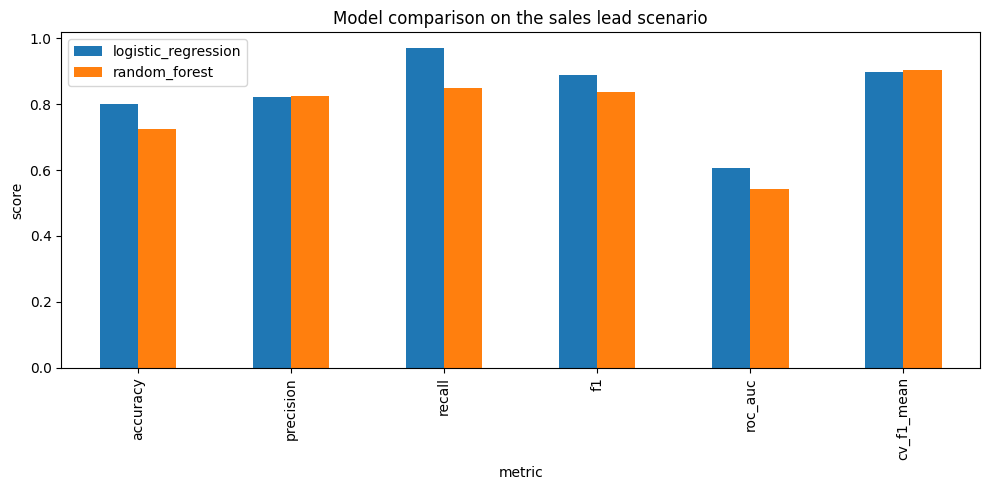

In [10]:
artifacts = ROOT / 'artifacts'
artifacts.mkdir(exist_ok=True)

ax = comparison.set_index('metric').plot(kind='bar', figsize=(10, 5), title='Model comparison on the sales lead scenario')
ax.set_ylabel('score')
ax.figure.tight_layout()
plt.savefig(artifacts / 'metrics_comparison.png', dpi=160)
plt.show()


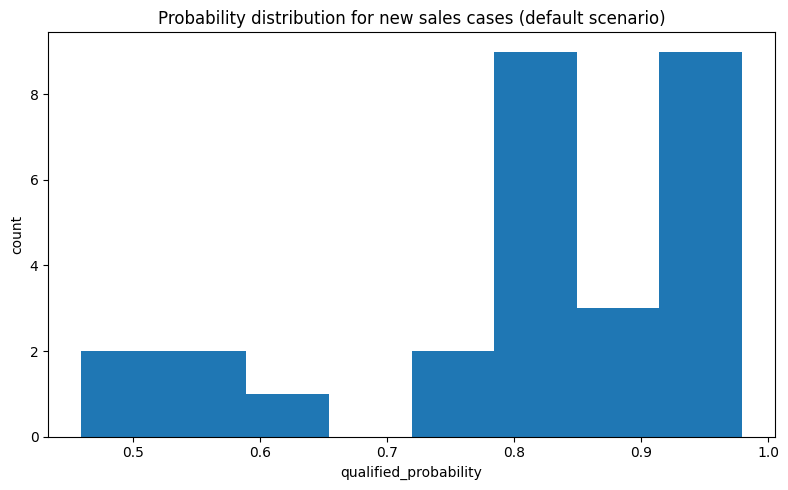

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(preds_default['qualified_probability'], bins=8)
plt.title('Probability distribution for new sales cases (default scenario)')
plt.xlabel('qualified_probability')
plt.ylabel('count')
plt.tight_layout()
plt.savefig(artifacts / 'prediction_distribution.png', dpi=160)
plt.show()


## 5) Execute the generated CWL workflow

In [12]:
print('To execute the portable workflow, run:')
print('cd generated_cwl && cwltool workflow.cwl inputs.yml')
print('Current generated CWL files:')
print(sorted([p.name for p in generated_dir.iterdir()]))


To execute the portable workflow, run:
cd generated_cwl && cwltool workflow.cwl inputs.yml
Current generated CWL files:
['dsl_config.json', 'evaluation_report.json', 'inputs.yml', 'lead_model.joblib', 'new_case_predictions.csv', 'score_cases.cwl', 'train_model.cwl', 'validate_data.cwl', 'validation_report.json', 'workflow.cwl']


In [13]:
portable_outputs = ['validation_report.json', 'evaluation_report.json', 'new_case_predictions.csv']
{k: (generated_dir / k).exists() for k in portable_outputs}


{'validation_report.json': True,
 'evaluation_report.json': True,
 'new_case_predictions.csv': True}

## 6) Summary

- The DSL is concise enough for domain experts to read and modify.
- textX handles parsing + model creation.
- The processor turns the DSL into reusable CWL CommandLineTools and a Workflow.
- The same domain specification supports both **local execution** and **portable workflow execution** through CWL.
